# EXPLORATORY DATA ANALYSIS - EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "../Dataset/"
train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")


In [3]:
train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
train.shape

(593994, 13)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [6]:
train.isnull().sum()


id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [7]:
train.duplicated().sum()


np.int64(0)

In [8]:
train.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442236,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


## Target Variable Analysis

In [9]:
train.loan_paid_back.value_counts()

loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

In [10]:
train.loan_paid_back.value_counts(normalize=True)

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

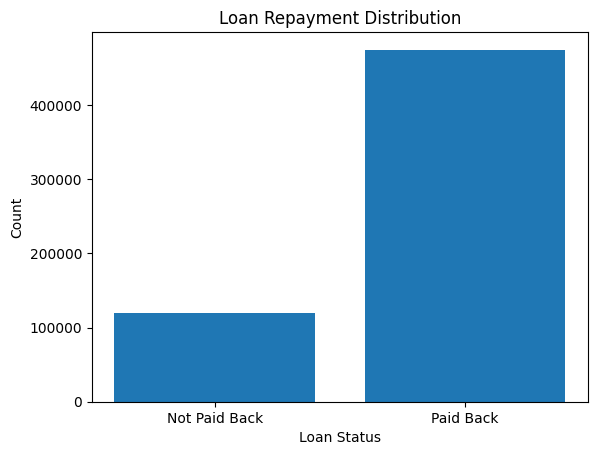

In [11]:

counts = train['loan_paid_back'].value_counts().sort_index()

plt.figure()
plt.bar(['Not Paid Back', 'Paid Back'], counts.values)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Loan Repayment Distribution')
plt.show()

## Univariate Analysis

> Numerical variables analysis



In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'annual_income', 'debt_to_income_ratio', 'credit_score',
    'loan_amount', 'interest_rate'
]
rename_dict = {
    'annual_income': 'Annual Income',
    'debt_to_income_ratio': 'Debt-to-Income Ratio',
    'credit_score': 'Credit Score',
    'loan_amount': 'Loan Amount',
    'interest_rate': 'Interest Rate'
}



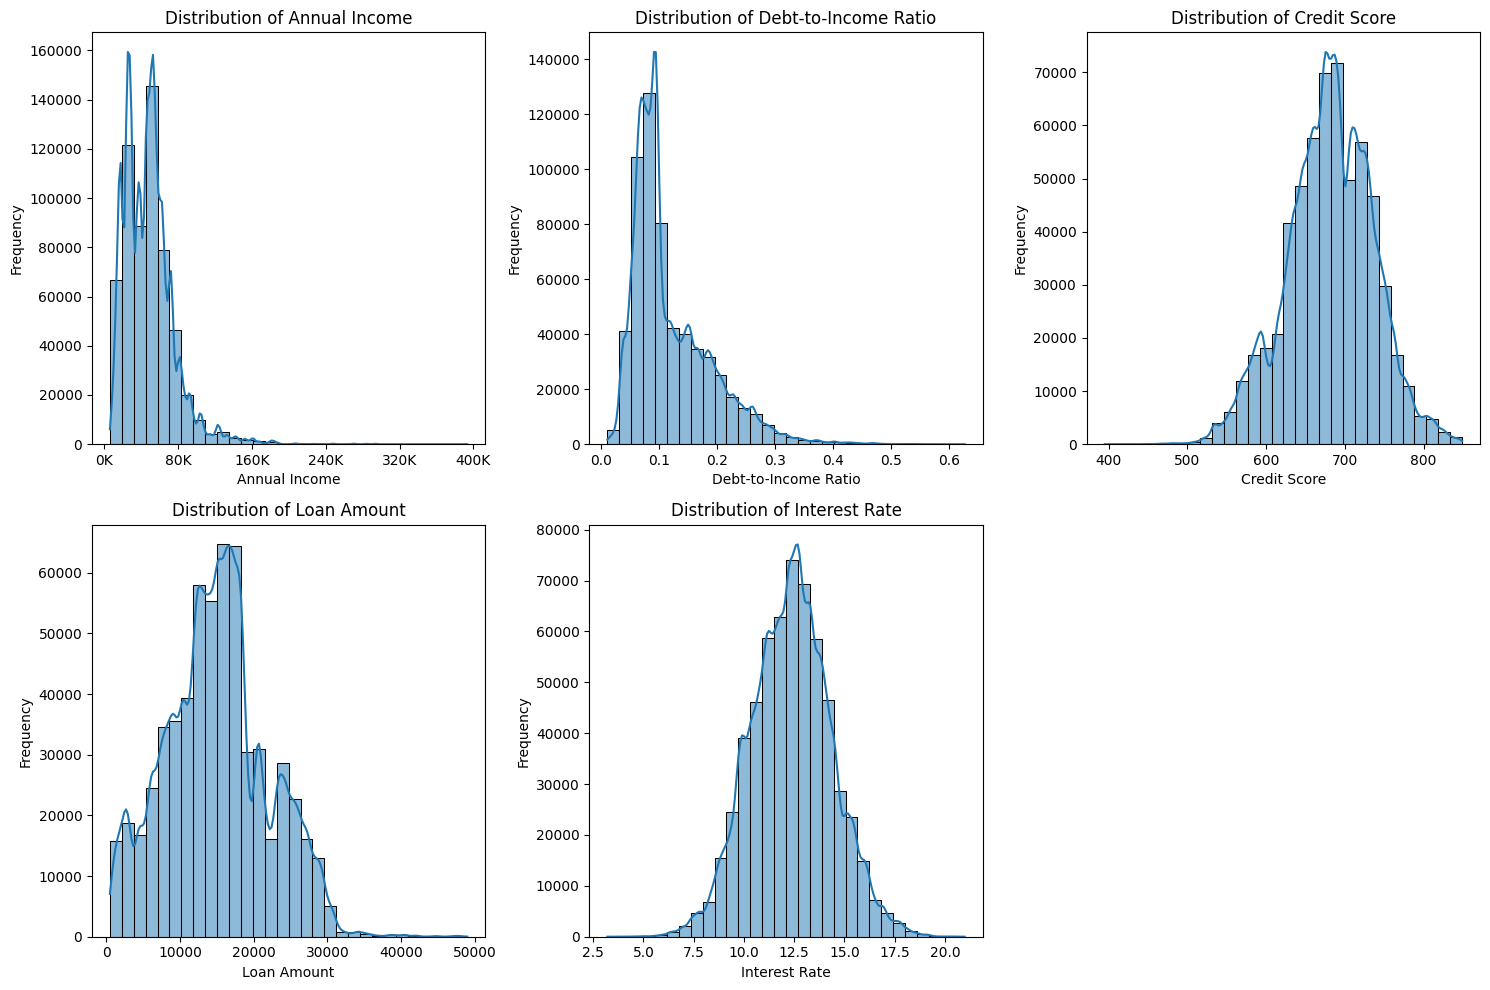

In [29]:
import matplotlib.ticker as mtick

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    ax = plt.subplot(2, 3, i + 1)
    sns.histplot(train[col], bins=30, kde=True)

    nice_name = rename_dict[col]
    ax.set_title(f'Distribution of {nice_name}', fontsize=12)
    ax.set_xlabel(nice_name)
    ax.set_ylabel('Frequency')

    # Fix clutter only for Annual Income
    if col == 'annual_income':
        ax.xaxis.set_major_locator(mtick.MaxNLocator(6))
        ax.xaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
        )

plt.tight_layout()
plt.show()


> Categorical Variable Analysis

In [14]:
cat_col = ['gender', 'marital_status', 'education_level',
            'employment_status', 'loan_purpose', 'grade_subgrade']

for col in cat_col:
    print(train[col].value_counts())
    print("-"*40)


gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64
----------------------------------------
marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64
----------------------------------------
education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64
----------------------------------------
employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64
----------------------------------------
loan_purpose
Debt consolidation    324695
Other                  63874
Car                    58108
Home                   44118
Education              36641
Business               35303
Medical                22806
Vacation                8449
Name: count, dtype: int64
----------------------------------------
grade_s

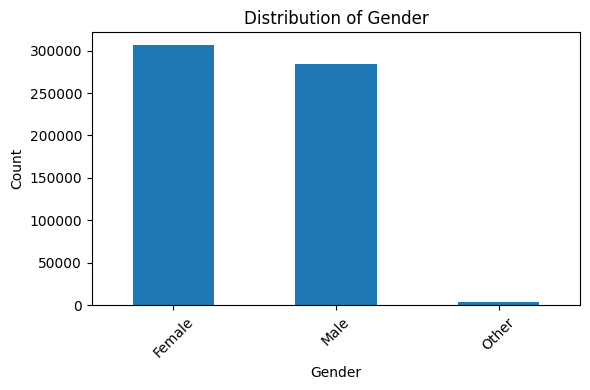

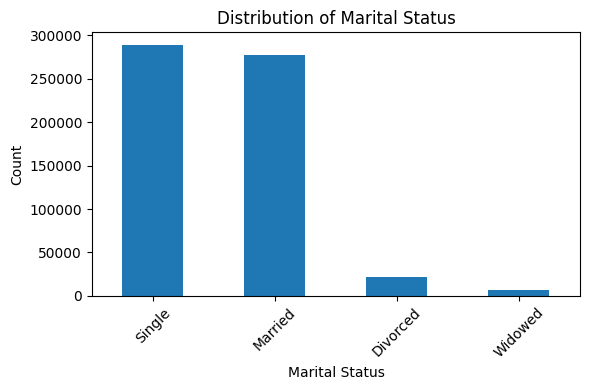

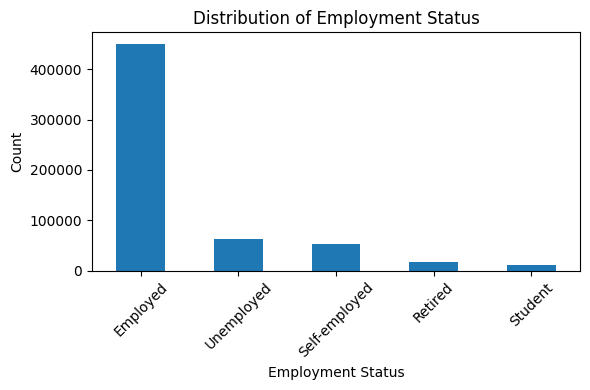

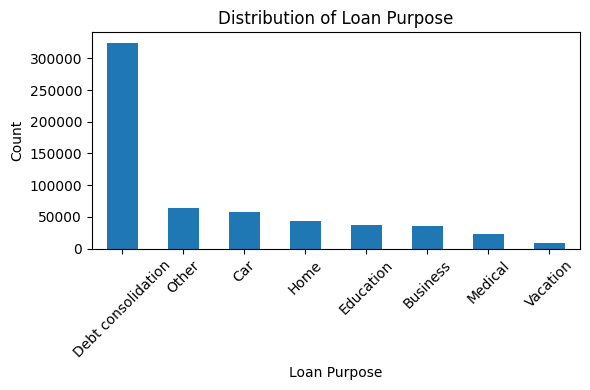

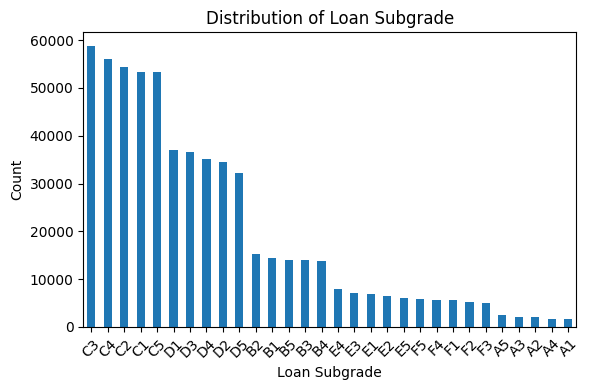

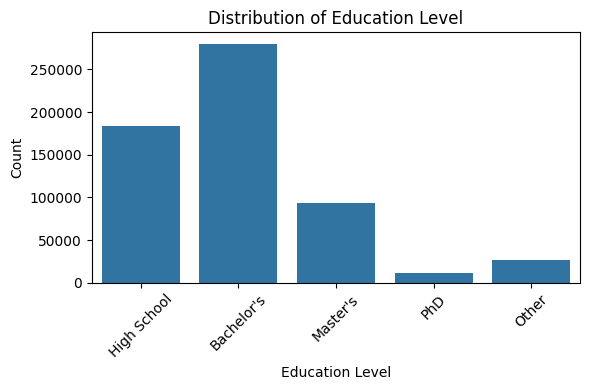

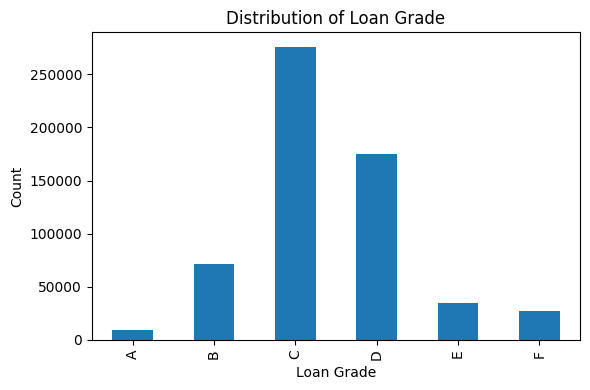

In [15]:
#train['grade'] = train['grade_subgrade'].str[0]
#edu_order = ['High School', "Bachelor's", "Master's", 'PhD', 'Other']
renamed_dict = {
    'gender': 'Gender',
    'marital_status': 'Marital Status',
    'employment_status': 'Employment Status',
    'loan_purpose': 'Loan Purpose',
    'grade_subgrade': 'Loan Subgrade',
    'grade': 'Loan Grade'
}

train['grade'] = train['grade_subgrade'].str[0]

cat_cols = ['gender', 'marital_status', 
            'employment_status', 'loan_purpose',
            'grade_subgrade']

for col in cat_cols:
    nice_name = renamed_dict[col]
    
    plt.figure(figsize=(6,4))
    train[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {nice_name}")
    plt.xlabel(nice_name)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

edu_order = ['High School', "Bachelor's", "Master's", 'PhD', 'Other']

plt.figure(figsize=(6,4))
sns.countplot(x='education_level', data=train, order=edu_order)
plt.xticks(rotation=45)
plt.title("Distribution of Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
train['grade'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Bivariate Analysis

>Numerical Variable Analysis

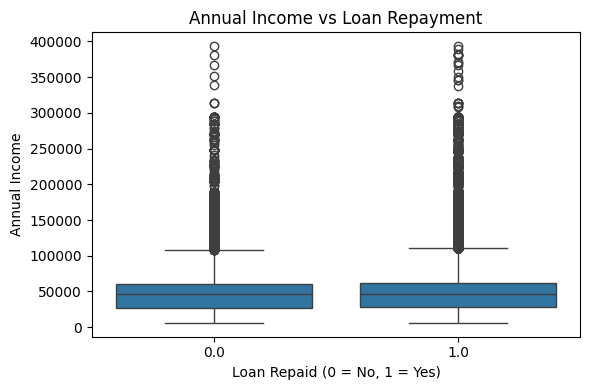

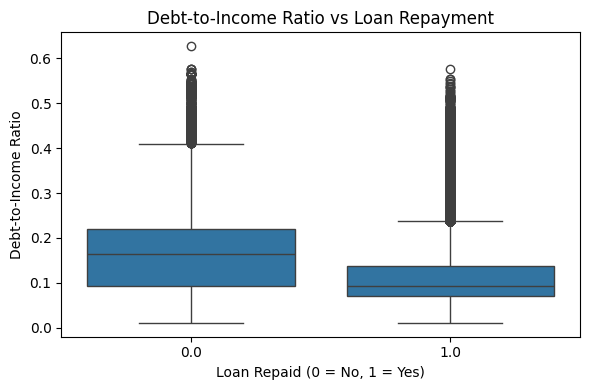

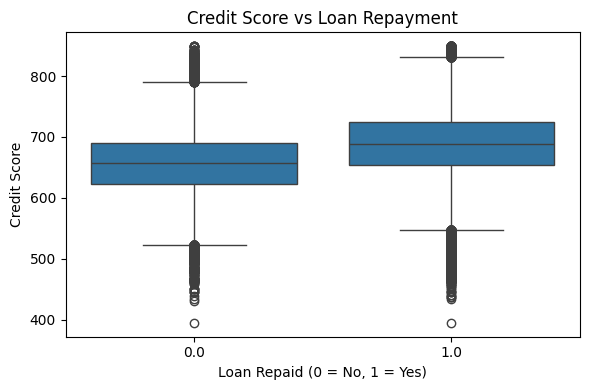

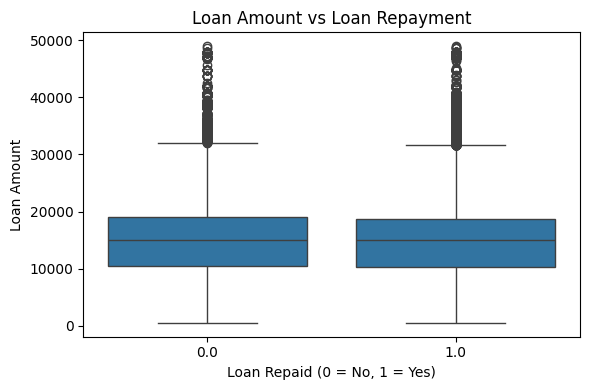

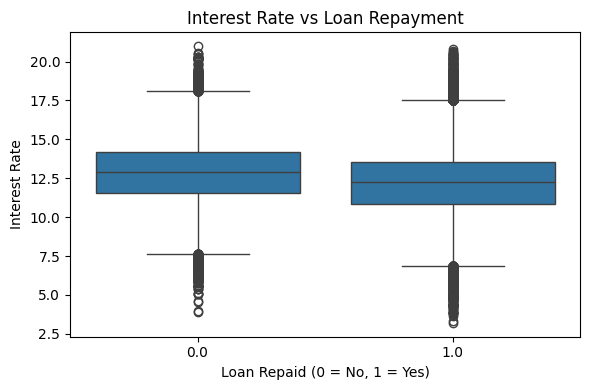

In [16]:
for col in num_cols:
    nice_name = rename_dict[col]
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x='loan_paid_back', y=col, data=train)
    
    plt.title(f"{nice_name} vs Loan Repayment")
    plt.xlabel("Loan Repaid (0 = No, 1 = Yes)")
    plt.ylabel(nice_name)
    
    plt.tight_layout()
    plt.show()


> Categorical Variable Analysis

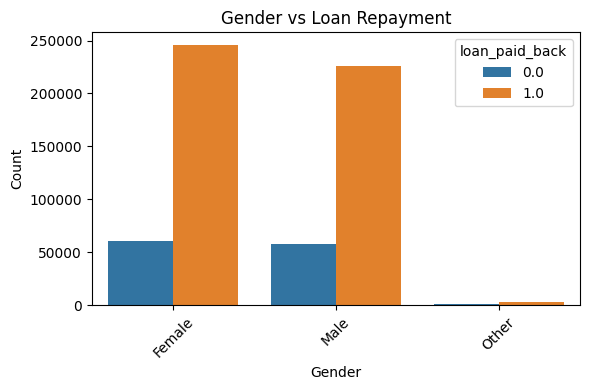

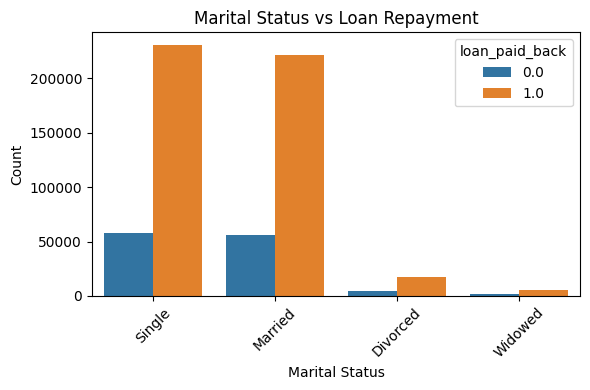

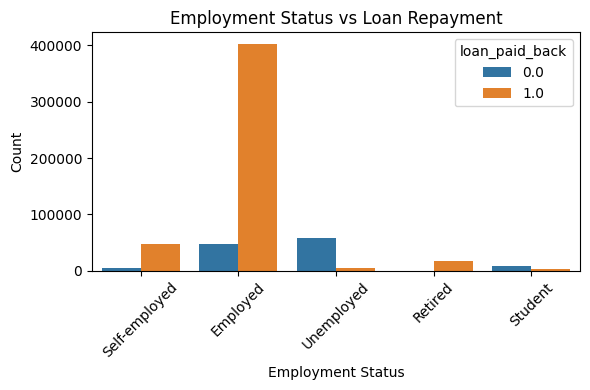

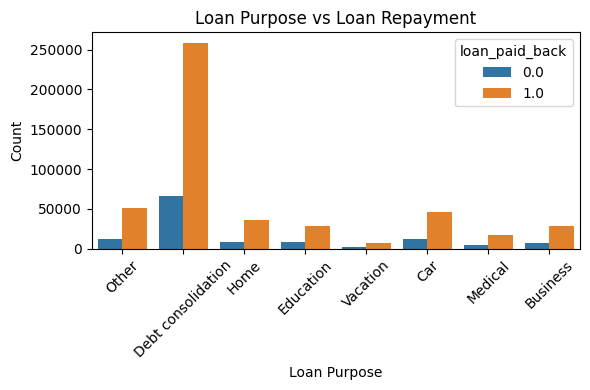

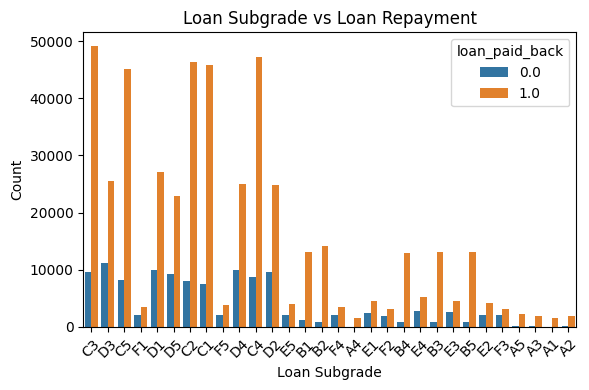

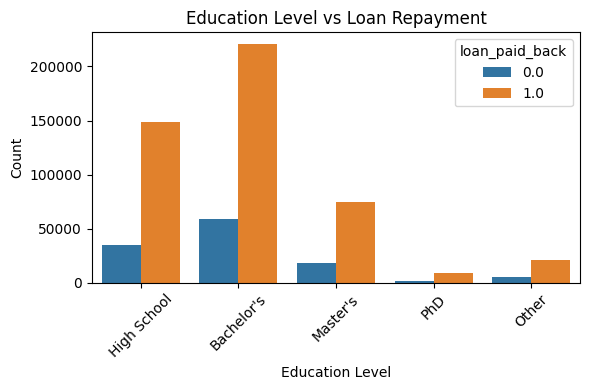

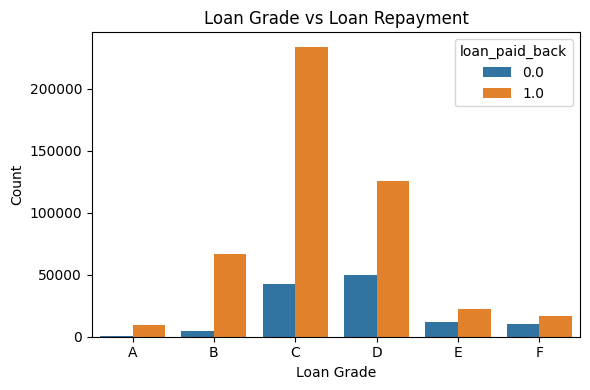

In [17]:
for col in cat_cols:
    nice_name = renamed_dict.get(col, col.replace('_', ' ').title())

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='loan_paid_back', data=train)
    plt.xticks(rotation=45)
    plt.title(f"{nice_name} vs Loan Repayment")
    plt.xlabel(nice_name)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# 2) Education (ordered)
plt.figure(figsize=(6,4))
sns.countplot(x='education_level',
              hue='loan_paid_back',
              data=train,
              order=edu_order)
plt.xticks(rotation=45)
plt.title("Education Level vs Loan Repayment")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3) Grade (A–F or A–G depending on your data)
grade_order = sorted(train['grade'].dropna().unique())

plt.figure(figsize=(6,4))
sns.countplot(x='grade',
              hue='loan_paid_back',
              data=train,
              order=grade_order)
plt.title("Loan Grade vs Loan Repayment")
plt.xlabel("Loan Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Correlation Analysis

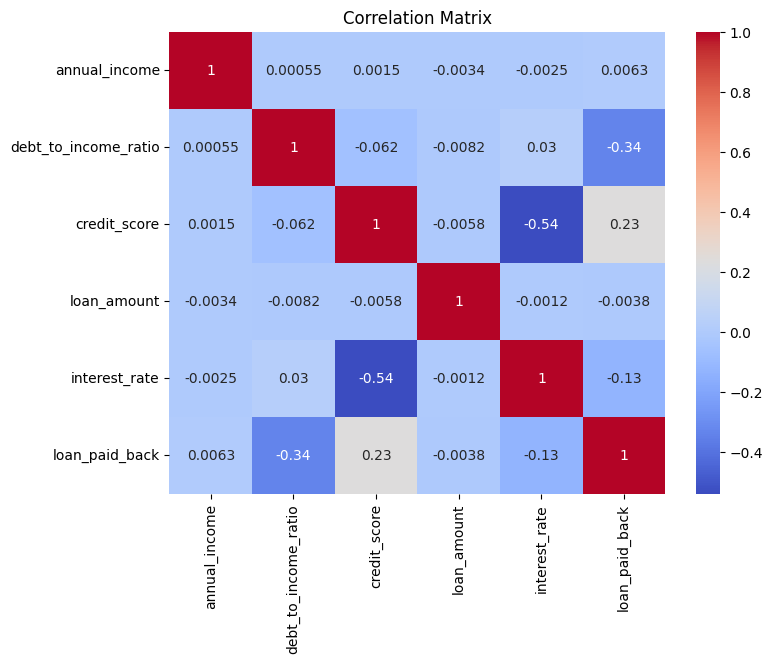

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols + ['loan_paid_back']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [19]:
grade_order = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
train['grade_encoded'] = train['grade'].map(grade_order)

edu_order = {
    'High School':0,
    "Bachelor's":1,
    "Master's":2,
    'PhD':3,
    'Other':4   # or place last depending on meaning
}

train['education_encoded'] = train['education_level'].map(edu_order)


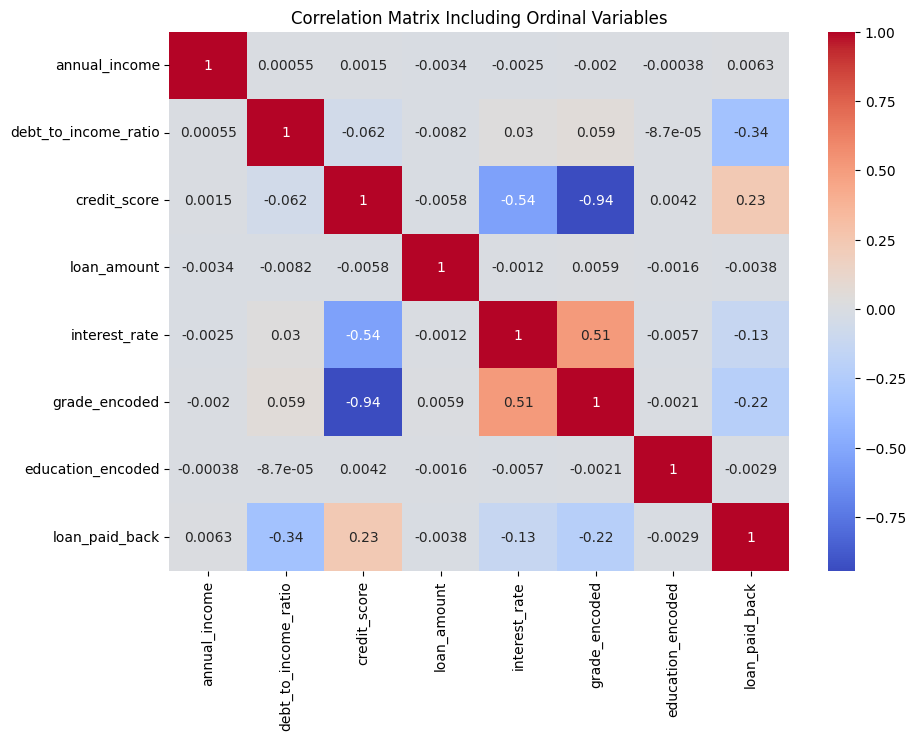

In [20]:
corr_cols = num_cols + ['grade_encoded', 
                        'education_encoded',
                        'loan_paid_back']

plt.figure(figsize=(10,7))
sns.heatmap(train[corr_cols].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Including Ordinal Variables")
plt.show()


In [21]:
letters = ['A','B','C','D','E','F']
numbers = ['1','2','3','4','5']

ordered_subgrades = [l+n for l in letters for n in numbers]

subgrade_mapping = {grade: i+1 for i, grade in enumerate(ordered_subgrades)}

train['subgrade_encoded'] = train['grade_subgrade'].map(subgrade_mapping)

edu_mapping = {
    'High School':1,
    "Bachelor's":2,
    "Master's":3,
    'PhD':4,
    'Other':0
}



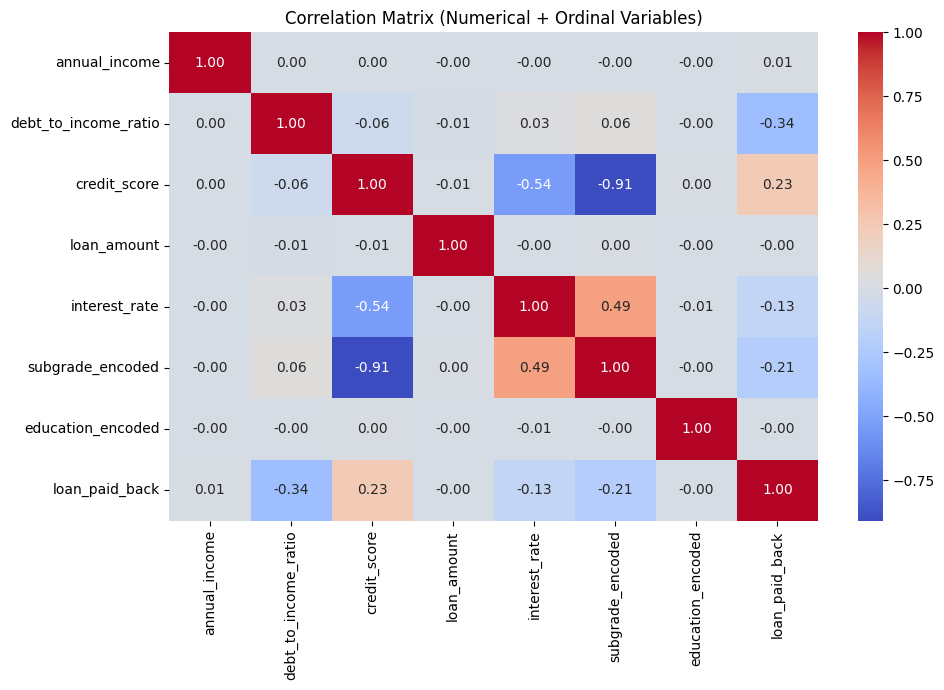

In [22]:
corr_cols = num_cols + [
    'subgrade_encoded',
    'education_encoded',
    'loan_paid_back'
]

plt.figure(figsize=(10,7))
sns.heatmap(
    train[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix (Numerical + Ordinal Variables)")
plt.tight_layout()
plt.show()


## Multivariate Analysis


In [23]:
train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back', 'grade', 'grade_encoded',
       'education_encoded', 'subgrade_encoded'],
      dtype='object')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_37116\2992445130.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = train.pivot_table(


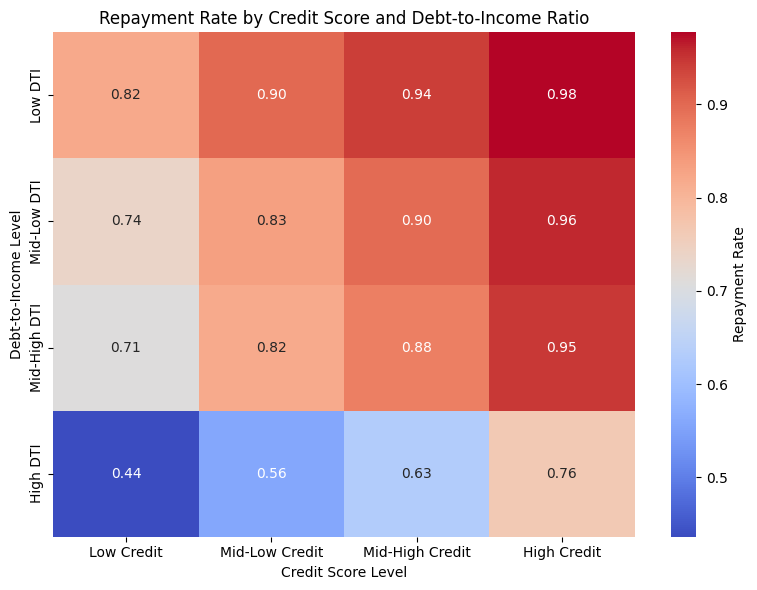

In [24]:
# Create clean bins
train['dti_bin'] = pd.qcut(train['debt_to_income_ratio'], 4,
                           labels=['Low DTI','Mid-Low DTI','Mid-High DTI','High DTI'])

train['credit_bin'] = pd.qcut(train['credit_score'], 4,
                              labels=['Low Credit','Mid-Low Credit','Mid-High Credit','High Credit'])

pivot = train.pivot_table(
    values='loan_paid_back',
    index='dti_bin',
    columns='credit_bin',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar_kws={'label': 'Repayment Rate'})

plt.title("Repayment Rate by Credit Score and Debt-to-Income Ratio")
plt.ylabel("Debt-to-Income Level")
plt.xlabel("Credit Score Level")
plt.tight_layout()
plt.show()
